In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np

In [122]:
train_path = '/content/drive/MyDrive/Kaggle_data/m13comp/train.parquet'
test_path = '/content/drive/MyDrive/Kaggle_data/m13comp/test.csv'

df = pd.read_parquet(train_path)
test_df = pd.read_csv(test_path)

df

,timestamp,station_id,temperature,humidity,wind
0,2000-04-01 00:00:00,1,14.520706,69.998333,4.046831
1,2000-04-01 01:00:00,1,15.911492,69.998333,4.046831
2,2000-04-01 02:00:00,1,13.301754,69.998333,4.046831
3,2000-04-01 03:00:00,1,14.365540,69.998333,4.046831
4,2000-04-01 04:00:00,1,13.145509,69.998333,4.046831
...,...,...,...,...,...
6255979,2024-05-31 19:00:00,31,24.302536,60.024836,4.999833
6255980,2024-05-31 20:00:00,31,22.693778,60.024836,4.999833
6255981,2024-05-31 21:00:00,31,25.320728,60.024836,4.999833
6255982,2024-05-31 22:00:00,31,24.480543,60.024836,4.999833


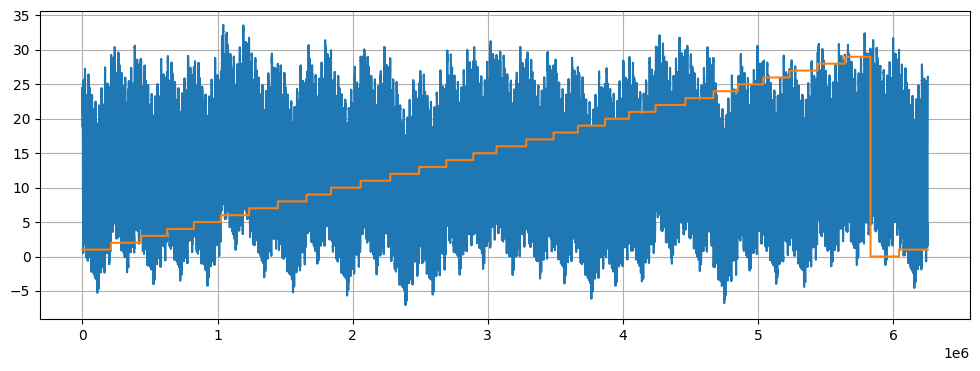

In [29]:
import matplotlib.pyplot as plt

df["temperature"].rolling(500).mean().plot(figsize=(12,4))
(df["station_id"] % 30).plot()
plt.grid()
plt.show()

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Базовый взгляд на данные
print("Data shape:", df.shape)
print("\nDate range:", df.index.min(), "to", df.index.max())
print("\nMissing values:")
print(df.isnull().sum())

Data shape: (6255984, 4)

Date range: 1999-01-27 00:00:00 to 2024-05-31 23:00:00

Missing values:
station_id     0
temperature    0
humidity       0
wind           0
dtype: int64


In [124]:
df['temperature'] = df.apply(
    lambda row: (row['temperature'] - 32) * 5/9 if row['temperature'] > 40 else row['temperature'],
    axis=1
)

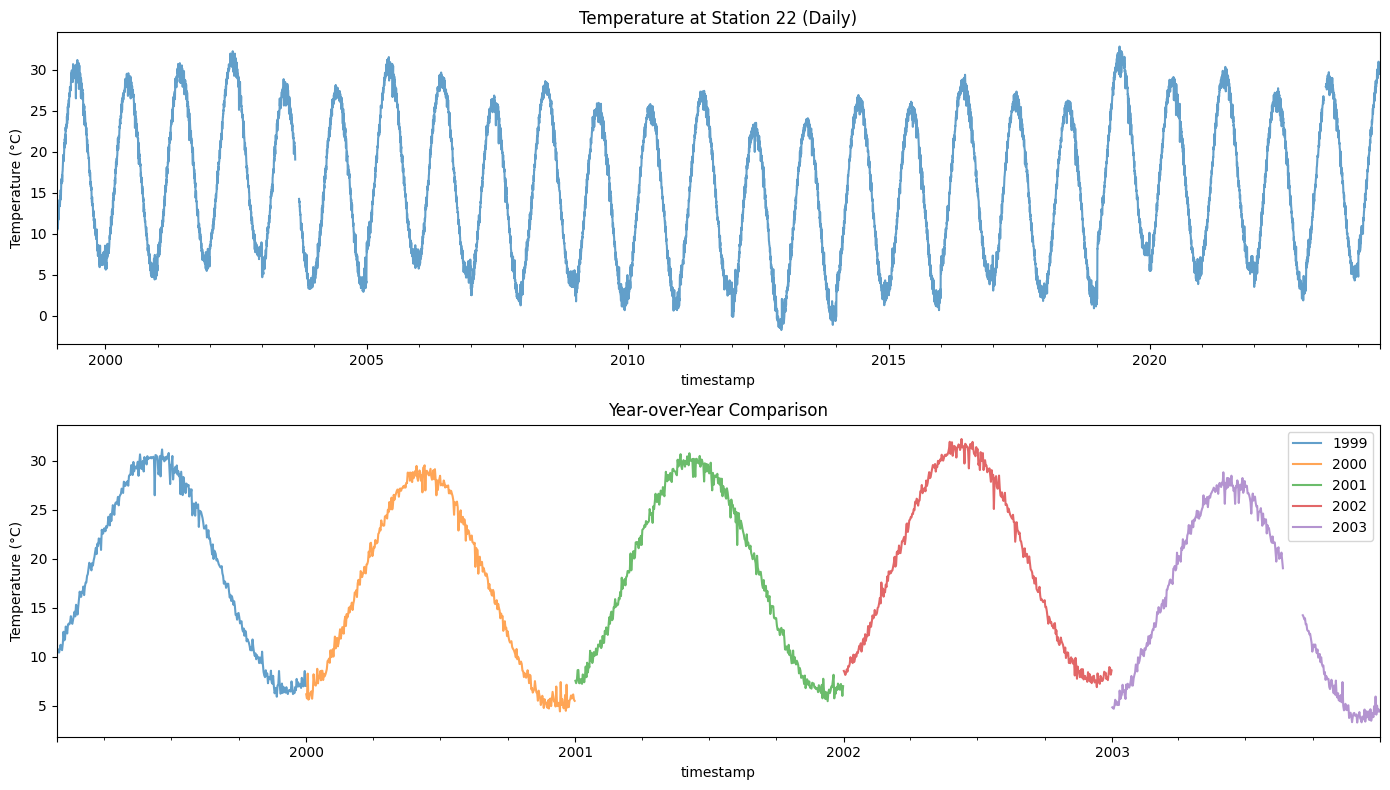

-10.0


In [54]:
# Выбираем одну станцию для анализа
station_id = df['station_id'].value_counts().index[0]
station_data = df[df['station_id'] == station_id].copy()

# Визуализация температуры по времени
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Ежедневная температура (средняя за день)
daily_temp = station_data['temperature'].resample('D').mean()
daily_temp.plot(ax=axes[0], alpha=0.7)
axes[0].set_title(f'Temperature at Station {station_id} (Daily)')
axes[0].set_ylabel('Temperature (°C)')

# Годовая сезонность (накладываем годы друг на друга)
years = station_data.index.year.unique()
for year in years[:5]:  # первые 5 лет для наглядности
    year_data = station_data[station_data.index.year == year]
    year_data['temperature'].resample('D').mean().plot(
        ax=axes[1], label=str(year), alpha=0.7
    )
axes[1].set_title('Year-over-Year Comparison')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(station_data['temperature'].min())

In [55]:
station_data['dayofyear'] = station_data.index.dayofyear
daily_climatology = station_data.groupby('dayofyear')['temperature'].agg(['min', 'max'])

# Предсказание для лета 2025
summer_2025 = pd.date_range('2025-06-01', '2025-08-31', freq='D')
summer_2025_doy = summer_2025.dayofyear

predicted_temps = daily_climatology.loc[summer_2025_doy, ['min', 'max']].values

print("\nSummer 2025 predictions:")

print(predicted_temps)


Summer 2025 predictions:
[[-10.          37.75983046]
 [-10.          37.76162905]
 [-10.          36.57151173]
 [ 16.82294251  39.27292315]
 [-10.          38.19397481]
 [-10.          39.73320537]
 [-10.          37.23474568]
 [-10.          38.93193798]
 [-10.          36.8989509 ]
 [-10.          38.15589106]
 [-10.          38.18965246]
 [-10.          38.1245193 ]
 [-10.          37.27286475]
 [-10.          38.63646035]
 [-10.          36.69043781]
 [-10.          36.64577637]
 [-10.          36.8168046 ]
 [-10.          37.3846244 ]
 [-10.          37.62818408]
 [-10.          36.4303998 ]
 [-10.          38.23020991]
 [-10.          37.99979572]
 [-10.          36.10689272]
 [-10.          36.51394476]
 [-10.          37.83157647]
 [-10.          37.40995671]
 [-10.          39.34007089]
 [-10.          37.67188788]
 [-10.          36.45814841]
 [-10.          35.87175389]
 [-10.          38.81336388]
 [-10.          37.274275  ]
 [-10.          36.81744868]
 [-10.          3

In [58]:
station_data = df[df['station_id'] == 2].copy()
daily_agg = station_data.resample('D').agg({
    'temperature': ['min', 'max'],
    'station_id': 'first'
})

# Убираем мультииндекс колонок
daily_agg.columns = ['temp_min', 'temp_max', 'station_id']

# Добавляем dayofyear
daily_agg['dayofyear'] = daily_agg.index.dayofyear

# Строим климатологию: для каждого дня года вычисляем медиану min и медиану max
climatology = daily_agg.groupby('dayofyear').agg({
    'temp_min': 'median',  # или 'mean'
    'temp_max': 'median'
}).reset_index()

climatology[120:260]

,dayofyear,temp_min,temp_max
120,121,18.316376,29.069540
121,122,17.885919,29.715531
122,123,18.078376,29.421852
123,124,18.814205,29.206749
124,125,18.516174,29.868613
...,...,...,...
255,256,8.165179,19.556813
256,257,7.599659,19.233141
257,258,7.335651,17.920360
258,259,8.112973,18.326362


In [125]:
submission_rows = []
summer_2025 = pd.date_range('2024-06-01', '2024-08-31', freq='D')

for i in range(1, 31):
    station_data = df[df['station_id'] == i].copy()
    daily_agg = station_data.resample('D').agg({
        'temperature': ['min', 'max'],
    })
    daily_agg.columns = ['temp_min', 'temp_max']
    daily_agg['dayofyear'] = daily_agg.index.dayofyear

    climatology = daily_agg.groupby('dayofyear').agg({
        'temp_min': 'median',
        'temp_max': 'median'
    }).reset_index()

    for date in summer_2025:
        doy = date.dayofyear

        row = climatology[climatology['dayofyear'] == doy]

        if len(row) > 0:
            temp_min = row['temp_min'].iloc[0]
            temp_max = row['temp_max'].iloc[0]
        else :
            temp_min = np.nan
            temp_max = np.nan

        # Добавляем строку для max
        submission_rows.append({
            'station_id': i,
            'timestamp': date.strftime('%Y-%m-%d 00:00:00'),
            'measure_type': 'max',
            'temperature': temp_max
        })
        submission_rows.append({
            'station_id': i,
            'timestamp': date.strftime('%Y-%m-%d 00:00:00'),
            'measure_type': 'min',
            'temperature': temp_min
        })

In [111]:
submission_df = pd.DataFrame(submission_rows)
submission_df

,station_id,timestamp,measure_type,temperature
0,1,2024-06-01 00:00:00,max,27.872699
1,1,2024-06-01 00:00:00,min,16.287469
2,1,2024-06-02 00:00:00,max,28.660481
3,1,2024-06-02 00:00:00,min,16.491353
4,1,2024-06-03 00:00:00,max,28.120981
...,...,...,...,...
5515,30,2024-08-29 00:00:00,min,11.362828
5516,30,2024-08-30 00:00:00,max,23.084103
5517,30,2024-08-30 00:00:00,min,10.063534
5518,30,2024-08-31 00:00:00,max,22.482841


In [67]:
submission_df.to_csv('/content/drive/MyDrive/Kaggle_data/m13comp/submission.csv', index=False)

In [126]:
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
submission_df['timestamp'] = pd.to_datetime(submission_df['timestamp'])

test_with_pred = test_df.merge(submission_df, on=['station_id', 'timestamp', 'measure_type'], how='left')


In [113]:
test_with_pred.columns

Index(['ID', 'station_id', 'timestamp', 'measure_type', 'temperature'], dtype='object')

In [114]:
test_with_pred

,ID,station_id,timestamp,measure_type,temperature
0,0,1,2024-06-01,max,27.872699
1,1,1,2024-06-01,min,16.287469
2,2,1,2024-06-02,max,28.660481
3,3,1,2024-06-02,min,16.491353
4,4,1,2024-06-03,max,28.120981
...,...,...,...,...,...
5699,5699,31,2024-08-29,min,NaN
5700,5700,31,2024-08-30,max,NaN
5701,5701,31,2024-08-30,min,NaN
5702,5702,31,2024-08-31,max,NaN


In [115]:
test_with_pred.isna().sum()

,0
ID,0
station_id,0
timestamp,0
measure_type,0
temperature,184


In [120]:
submission_df

,station_id,timestamp,measure_type,temperature
0,1,2024-06-01,max,27.872699
1,1,2024-06-01,min,16.287469
2,1,2024-06-02,max,28.660481
3,1,2024-06-02,min,16.491353
4,1,2024-06-03,max,28.120981
...,...,...,...,...
5515,30,2024-08-29,min,11.362828
5516,30,2024-08-30,max,23.084103
5517,30,2024-08-30,min,10.063534
5518,30,2024-08-31,max,22.482841


In [127]:
submission_df["timestamp"] = pd.to_datetime(test_with_pred["timestamp"])
submission_df['doy'] = submission_df["timestamp"].dt.dayofyear

test_with_pred["timestamp"] = pd.to_datetime(test_with_pred["timestamp"])
test_with_pred["doy"] = test_with_pred["timestamp"].dt.dayofyear

minmax_stats = submission_df.groupby(['station_id', 'doy']).agg({'temperature': ['min', 'max']})
minmax_stats.columns = ['min', 'max']
minmax_stats = minmax_stats.reset_index()

median_by_day = minmax_stats.groupby('doy')[['min', 'max']].median()

test_with_pred = test_with_pred.merge(median_by_day, left_on="doy", right_index=True, how="left")
test_with_pred.columns

Index(['ID', 'station_id', 'timestamp', 'measure_type', 'temperature', 'doy',
       'min', 'max'],
      dtype='object')

In [128]:
test_with_pred['median_value'] = np.where(test_with_pred['measure_type'] == 'min',
                                          test_with_pred['min'],
                                          test_with_pred['max'])
test_with_pred['temperature'] = test_with_pred['temperature'].fillna(test_with_pred['median_value'])
final_test = test_with_pred[['ID','station_id',	'timestamp',	'measure_type',	'temperature']].copy()
final_test

,ID,station_id,timestamp,measure_type,temperature
0,0,1,2024-06-01,max,27.872699
1,1,1,2024-06-01,min,16.287469
2,2,1,2024-06-02,max,28.660481
3,3,1,2024-06-02,min,16.491353
4,4,1,2024-06-03,max,28.120981
...,...,...,...,...,...
5699,5699,31,2024-08-29,min,9.046551
5700,5700,31,2024-08-30,max,20.409658
5701,5701,31,2024-08-30,min,9.263516
5702,5702,31,2024-08-31,max,20.469343


In [129]:
final_submission = final_test[['ID', 'temperature']]
final_submission

,ID,temperature
0,0,27.872699
1,1,16.287469
2,2,28.660481
3,3,16.491353
4,4,28.120981
...,...,...
5699,5699,9.046551
5700,5700,20.409658
5701,5701,9.263516
5702,5702,20.469343


In [130]:
final_submission.to_csv('/content/drive/MyDrive/Kaggle_data/m13comp/final_submission.csv', index=False)